# SR Tutorial

2026 IAIFI Summer School

Tutorial lead: Jose M Munoz

Professor: Miles Cranmer

# Extras: Teaching PySR New Words

Nothing in here is part of the taught sessions. It is the answer sheet for the questions that
tend to arrive at the end, the ones that begin "can it also...", and you are welcome to work
through it at your own pace afterwards.

The whole notebook runs on one small problem so that nothing competes for your attention with
the feature being shown. We have a tracer diffusing into a long bar from one end, we know the
depth and the time of every reading, and we would like the law back. The interesting part is
that the law is not built out of the operators PySR ships with, so we are going to have to hand
it some new ones.

Along the way we pick up the surrounding machinery too, since the questions travel together:
how to keep an operator from crashing the search, how to get a usable equation back out
afterwards, how to write a loss that inspects the expression itself, and how to put a search
down and pick it up again later.

Everything here is live. The whole notebook runs in about four minutes on a laptop, rather more
on Colab, and a good part of that is Julia compiling rather than anything searching.

---

In [1]:
# Uncomment on Colab.
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pysr", "sympy>=1.14"], check=True)

In [2]:
import os
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import time

import numpy as np
import sympy

t0 = time.time()
import pysr
from pysr import PySRRegressor, jl
print(f"pysr {pysr.__version__} imported in {time.time() - t0:.0f}s")

import torch  # imported after pysr on purpose, see the note below

import session5_data as s5
from session5_data import measurements, measurable, front

# Serial and seeded so that everything below is reproducible; drop this for real work,
# where multithreading is much faster.
REPRO = dict(deterministic=True, parallelism="serial", random_state=0,
             verbosity=0, progress=False)

pysr 1.5.9 imported in 8s


Two small things about that cell. The `torch` import comes after `pysr` because juliacall and
torch fight over which one loads its libraries first, and doing it the other way round earns you
a segfault warning at best. And `REPRO` pins the search to a single thread with a fixed seed, so
your numbers should match the ones printed here; for any real search you want the default
multithreading instead.

## 1. The bar, and what came off it

A tracer diffuses into a long bar from the face at $x = 0$, which is held at unit concentration
from $t = 0$ onwards. A probe gives us the local concentration, and separately its gradient,
each reading taken at whatever depth and time we happened to reach.

300 readings, depth 0.02 to 2.49 cm, time 0.27 to 4.00 s


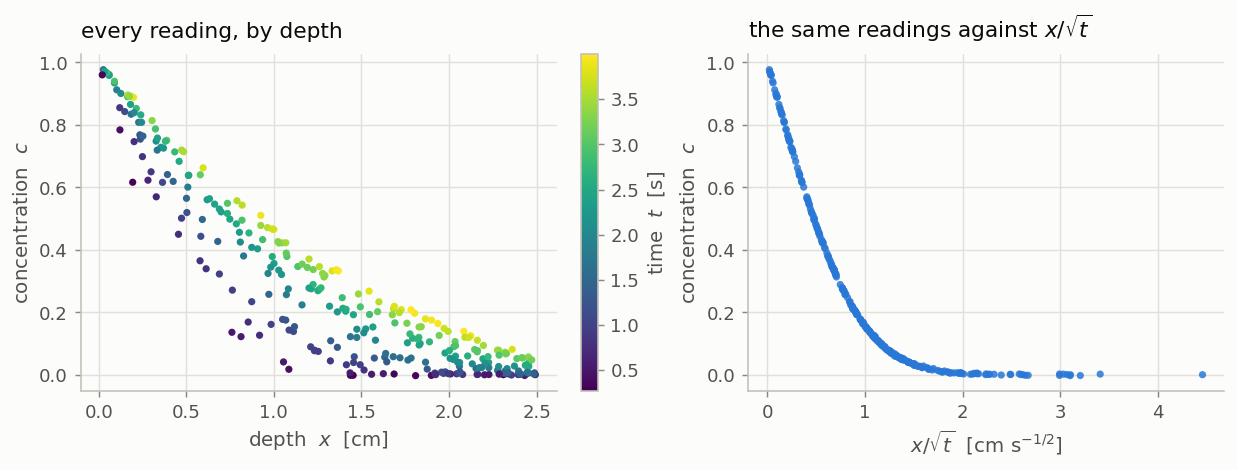

In [3]:
X, c, g = measurements(n=300, seed=0)
print(f"{X.shape[0]} readings, depth {X[:, 0].min():.2f} to {X[:, 0].max():.2f} cm, "
      f"time {X[:, 1].min():.2f} to {X[:, 1].max():.2f} s")
s5.plot_measurements(X, c)

The left panel is a mess, and reasonably so, because a reading taken late has had longer to
spread than one taken early. The right panel is the same numbers plotted against
$x/\sqrt{t}$, and they fall on a single curve. That collapse is the physics of the problem
announcing itself, and it means the answer we want is a function of one variable rather than
two.

The curve those points land on is the complementary error function,

$$c(x, t) = \operatorname{erfc}\!\left(\frac{x}{2\sqrt{Dt}}\right),$$

and we have set $D = 1/4\ \mathrm{cm^2/s}$ so that the answer is exactly
$\operatorname{erfc}(x/\sqrt{t})$. Nothing about erfc is available to PySR out of the box.

## 2. What a free search makes of it

Before we hand over anything, let us see how far the standard operators get on their own.

In [4]:
t0 = time.time()
free = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "sqrt"],
    **REPRO,
)
free.fit(X, c, variable_names=["x", "t"])
print(f"{time.time() - t0:.0f}s")
front(free)

18s


,complexity,loss,equation
0,1,0.082327,0.28566235
1,3,0.082327,1.2328213 + -0.9471437
2,4,0.007730,exp(x * -1.1893082)
3,6,0.006490,exp(x / (t * -0.39576533))
4,7,0.001606,exp((x * -1.6703881) / sqrt(t))
5,8,0.001606,sqrt(exp((x * -3.3406289) / sqrt(t)))
6,9,0.000918,exp((0.051294595 - (x / sqrt(t))) * 1.8280793)
7,11,0.000087,exp(x / ((-1.0451212 * t) / (x + sqrt(t))))
8,13,0.000005,exp(x / (t * (-1.3273724 / (sqrt(t / 0.4717325...
9,15,0.000004,exp(x / ((t / (x + sqrt(t + t))) * -1.3068777)...


Look at the row at complexity 7. The search has found $x/\sqrt{t}$ by itself, which is genuinely
impressive, and then it has had to fake the shape of the profile with an exponential because
that is the closest thing in its vocabulary. Everything below that row is the search buying
accuracy by bolting corrections onto the fake, and by complexity 30 we have a nest that no one
would put in a paper.

This is what a missing operator looks like from the outside. The search is not confused, it is
working hard with the wrong words.

## 3. An operator you write yourself

The gradient channel is the easier of the two to fix, since $-\partial c/\partial x$ is a
Gaussian and a Gaussian is one line of Julia. An operator is a string holding a Julia function
definition, and it needs a companion entry in `extra_sympy_mappings` so that PySR can convert
the result back into something SymPy understands afterwards.

In [5]:
t0 = time.time()
bump = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt", "gauss(x) = exp(-x*x)"],
    extra_sympy_mappings={"gauss": lambda z: sympy.exp(-(z ** 2))},
    **REPRO,
)
bump.fit(X, g, variable_names=["x", "t"])
print(f"{time.time() - t0:.0f}s")
front(bump)

15s


,complexity,loss,equation
0,1,0.102072,0.3616471
1,2,0.027282,gauss(x)
2,3,0.023108,gauss(sqrt(x))
3,5,0.020171,sqrt(gauss(x - -0.2631391))
4,6,0.015843,sqrt(gauss(x) / sqrt(t))
5,7,0.011073,(gauss(x) / sqrt(t)) + 0.11936448
6,8,0.003008,gauss(x / sqrt(t)) / sqrt(t)
7,10,0.000004,gauss(x / sqrt(t)) / sqrt(t * 0.7857388)
8,12,0.000004,(gauss(x * sqrt(1.0005676 / t)) * 1.1282876) /...
9,19,0.000004,(gauss(x / sqrt(t)) * 1.1281384) / sqrt(t + (0...


In [6]:
print(bump.sympy())
print("the fitted constant:", float(bump.sympy().as_coeff_Mul()[0]))
print("2/sqrt(pi):         ", 2 / np.sqrt(np.pi))

1.12813455087381*exp(-x**2/t)/sqrt(t)
the fitted constant: 1.128134550873808
2/sqrt(pi):          1.1283791670955126


So the search returns $\operatorname{gauss}(x/\sqrt{t})/\sqrt{t}$ with a prefactor it fitted
freely, and that prefactor is $2/\sqrt{\pi}$ to four figures. Nobody told it that constant, and
recognising a fitted float as something closed-form afterwards is usually a better move than
trying to force it during the search.

Three rules keep custom operators out of trouble, and the second one bites people most often.

Write the SymPy mapping with SymPy functions, never numpy or scipy, or export and `predict`
will break later even though the fit itself went fine. Preserve the input type, since the
default precision is Float32 and a bare `2.5` in your Julia definition is a Float64 that will
quietly de-optimise the whole search; write `2.5f0`, or take a `where {T}` signature and say
`T(2.5)`. And keep to one or two scalar arguments in and one scalar out, because three or more
needs either a template expression or PySR 2.0's n-ary `operators` dict.

## 4. Borrowing an operator from Julia

Writing erfc by hand is not something anyone should do before lunch, and we do not have to,
because the whole Julia package ecosystem is sitting underneath PySR and we can reach it. The
`jl` object is a live Julia runtime, so we install `SpecialFunctions` into it the same way we
would from a Julia REPL.

The install takes a little while the first time and is instant afterwards.

In [7]:
t0 = time.time()
jl.seval('import Pkg; Pkg.add("SpecialFunctions")')
jl.seval("import SpecialFunctions")          # import, not using: see the note below
print(f"SpecialFunctions ready in {time.time() - t0:.0f}s")
print("erfc(1) from Julia:", jl.seval("SpecialFunctions.erfc(1.0f0)"))

SpecialFunctions ready in 9s
erfc(1) from Julia: 0.15729920566082


   Resolving package versions...
  No Changes to `~/anaconda3/julia_env/Project.toml`
  No Changes to `~/anaconda3/julia_env/Manifest.toml`


Now it is an operator like any other. We name our operator `erfc` because that is what we want to
read on the front, and we reach the package's own function through the qualified
`SpecialFunctions.erfc` inside the definition.

That is also why we said `import SpecialFunctions` rather than `using SpecialFunctions`. A
`using` would drop the package's `erfc` into the same namespace where PySR is about to define
ours, and Julia will not let you define a function whose name already belongs to another module.
The error, if you ever meet it, complains that the name must be explicitly imported to be
extended, and the cure is either the qualified import we used here or a different operator name.

In [8]:
ERFC = "erfc(x) = SpecialFunctions.erfc(x)"
SYMPY_MAP = {"erfc": lambda z: sympy.erfc(z), "gauss": lambda z: sympy.exp(-(z ** 2))}

t0 = time.time()
known = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "sqrt", ERFC],
    extra_sympy_mappings=SYMPY_MAP,
    **REPRO,
)
known.fit(X, c, variable_names=["x", "t"])
print(f"{time.time() - t0:.0f}s")
front(known)

21s


,complexity,loss,equation
0,1,0.082327,0.28566176
1,2,0.017395,erfc(x)
2,3,0.010147,sqrt(erfc(x))
3,4,0.007367,erfc(x / 1.4288421)
4,5,0.000003,erfc(x / sqrt(t))
5,7,0.000003,erfc(x / sqrt(t)) * 0.99959004
6,9,0.000003,erfc(x * (1.002583 / (sqrt(t) + 0.0032001396)))
7,11,0.000003,erfc(x / ((t * sqrt(0.9955344 / t)) + 0.002739...
8,14,0.000003,erfc(x / ((sqrt(0.99861926 / t) + (erfc(t) * 0...
9,16,0.000003,erfc(x / sqrt(t - ((4.6986885 / (exp(t * 1.775...


 standard operators:  complexity  13   loss 5.13e-06   exp(x / (t * (-1.3273724 / (sqrt(t / 0.4717325) + x))))
          with erfc:  complexity   5   loss 3.47e-06   erfc(x / sqrt(t))

erfc(x/sqrt(t))


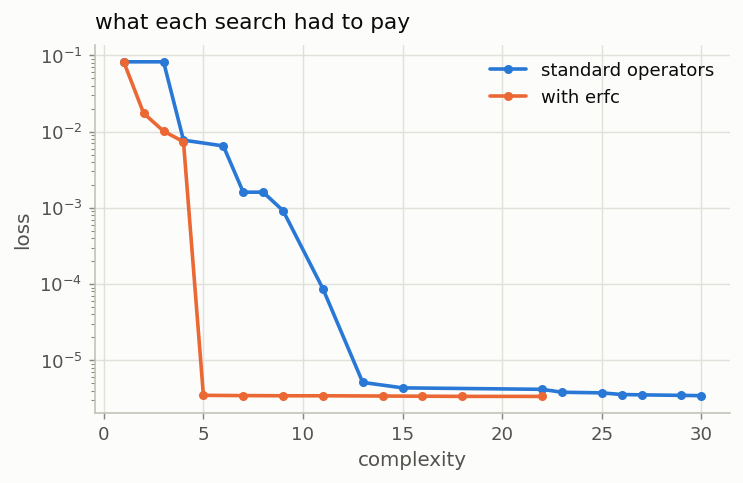

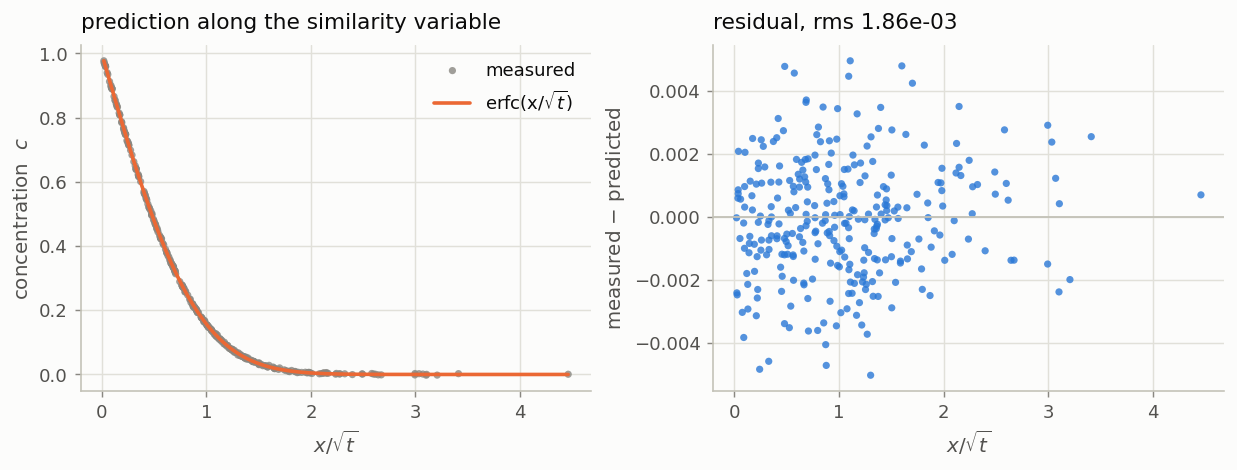

In [9]:
# What did each search have to spend to get as good as it got?
for label, model in [("standard operators", free), ("with erfc", known)]:
    row = s5.cheapest_within(model, factor=2.0)
    print(f"{label:>19}:  complexity {row['complexity']:>3}   loss {row['loss']:.2e}   {row['equation']}")
print()
print(known.sympy())

s5.plot_fronts({"standard operators": free.equations_, "with erfc": known.equations_})
s5.plot_check(X, c, known.predict(X), label="erfc(x/$\\sqrt{t}$)")

One operator, and the answer is $\operatorname{erfc}(x/\sqrt{t})$, five nodes, exactly the law we
set out to find. The comparison above asks each search what it had to spend to get within a
factor of two of its own best, which is a fairer question than comparing the bottom rows of two
fronts, and the free search pays thirteen nodes for what erfc says in five. The front plot makes
the same point: the two searches finish at the same accuracy and one of them buys it with a nest
that goes on to thirty nodes.

This is the whole argument for custom operators. You are not making the search cleverer, you are
making the thing you are looking for cheap to say.

## 5. An operator has to survive the whole real line

Now the trap. PySR probes every operator far outside your data before the search starts, and if
yours throws there, the run stops before it begins. To see it, let us run the problem backwards
and ask for the depth given a concentration reading, which needs the inverse function
$\operatorname{erfcinv}$, defined only on $(0, 2)$.

In [10]:
keep = measurable(c)                       # a real probe resolves neither rail
Xi = np.stack([c[keep], X[keep, 1]], axis=1)
depth = X[keep, 0]
print(f"{keep.sum()} of {len(c)} readings are in range")

try:
    naive = PySRRegressor(
        niterations=5,
        binary_operators=["*", "/"],
        unary_operators=["sqrt", "ierfc(x) = SpecialFunctions.erfcinv(x)"],
        extra_sympy_mappings={"ierfc": lambda z: sympy.erfcinv(z)},
        **REPRO,
    )
    naive.fit(Xi, depth, variable_names=["c", "t"])
except Exception as err:
    print(type(err).__name__)
    print(str(err).split("Stacktrace")[0].strip())

257 of 300 readings are in range


JuliaError
The operator `ierfc` is not well-defined over the real line, as it threw the error `DomainError` when evaluating the input -100.0. You can work around this by returning NaN for invalid inputs. For example, `safe_log(x::T) where {T} = x > 0 ? log(x) : T(NaN)`.


PySR catches this itself and tells you the fix, which is a kindness. The guard returns a NaN of
the right type for arguments outside the domain, and candidates that produce a NaN anywhere on
your data are discarded with infinite loss. That is exactly how a domain restriction should
behave during a search, so this is a feature rather than a workaround.

In [11]:
IERFC = "ierfc(x::T) where {T} = (zero(T) < x < T(2)) ? SpecialFunctions.erfcinv(x) : T(NaN)"

t0 = time.time()
inverse = PySRRegressor(
    niterations=40,
    binary_operators=["*", "/"],
    unary_operators=["sqrt", IERFC],
    extra_sympy_mappings={"ierfc": lambda z: sympy.erfcinv(z)},
    **REPRO,
)
inverse.fit(Xi, depth, variable_names=["c", "t"])
print(f"{time.time() - t0:.0f}s")
print(inverse.sympy())
front(inverse)

13s
sqrt(t)*erfcinv(c)


,complexity,loss,equation
0,1,0.504077,1.231136
1,2,0.288171,ierfc(c)
2,4,0.095122,ierfc(c) / 0.68329436
3,5,0.000154,ierfc(c) * sqrt(t)
4,7,0.000154,ierfc(c * 1.000697) * sqrt(t)
5,9,0.000154,(ierfc(c * 1.000697) * 0.99999034) * sqrt(t)
6,11,0.000154,(sqrt(t) * 0.9999952) * (ierfc(c * 1.000697) *...
7,17,0.000154,((0.99999034 * ((t / sqrt(t)) * ierfc(c * 1.00...
8,19,0.000154,(((t * ((t / sqrt(t)) * 1.000031)) / (t * 1.00...
9,23,0.000154,(ierfc(c * 1.000697) * ((t * ((1.0000155 * (t ...


Which is $x = \sqrt{t}\,\operatorname{erfcinv}(c)$, the profile solved for depth.

Note the `T(NaN)` rather than a plain `NaN`, and the `zero(T)` rather than a plain `0`. Both are
the type-preservation rule from earlier showing up again, and both matter for the same reason:
the search runs in Float32 and a stray Float64 poisons it.

The other half of why we filtered the readings first is worth saying out loud. A single NaN
anywhere invalidates a candidate, so if we had left the saturated readings in, every expression
containing `ierfc` would have died on the first point where noise pushed the concentration below
zero, and the search would have quietly reported that erfcinv was useless. When an operator with
a restricted domain seems to be ignored, look at the edges of your data before you blame the
operator.

## 6. Getting the equation back out

A fit you cannot export is half a result. SymPy and LaTeX come for free once the mapping is in
place, and `latex_table` gives you a Pareto front you can paste straight into a paper.

In [12]:
print(known.latex())
print()
print(known.latex_table(indices=[3, 4, 5]))

\operatorname{erfc}{\left(\frac{x}{\sqrt{t}} \right)}

\usepackage{breqn}
\usepackage{booktabs}

...

\begin{table}[h]
\begin{center}
\begin{tabular}{@{}cccc@{}}
\toprule
Equation & Complexity & Loss & Score \\
\midrule
$y = \operatorname{erfc}{\left(\frac{x}{1.43} \right)}$ & $4$ & $0.00737$ & $0.320$ \\
\begin{minipage}{0.8\linewidth} \vspace{-1em} \begin{dmath*} y = \operatorname{erfc}{\left(\frac{x}{\sqrt{t}} \right)} \end{dmath*} \end{minipage} & $5$ & $3.47 \cdot 10^{-6}$ & $7.66$ \\
\begin{minipage}{0.8\linewidth} \vspace{-1em} \begin{dmath*} y = 1.00 \operatorname{erfc}{\left(\frac{x}{\sqrt{t}} \right)} \end{dmath*} \end{minipage} & $7$ & $3.45 \cdot 10^{-6}$ & $0.00398$ \\
\bottomrule
\end{tabular}
\end{center}
\end{table}


PyTorch is the one that needs a second mapping, because the sympy-to-torch translation is a
different table. Ours fails first, on purpose, so you can recognise the error when you meet it.

In [13]:
try:
    known.pytorch()
except Exception as err:
    print(type(err).__name__, str(err)[:160])

known.set_params(extra_torch_mappings={sympy.erfc: torch.erfc})
known.refresh()                     # rebuilds the exports after a mapping change
module = known.pytorch()
print(module)

xt = torch.tensor(X[:4], dtype=torch.float32, requires_grad=True)
out = module(xt)
out.sum().backward()
print("predicted   ", out.detach().numpy())
print("measured    ", c[:4])
print("d/dx of it  ", xt.grad[:, 0].numpy())

KeyError 'Function erfc was not found in Torch function mappings.Please add it to extra_torch_mappings in the format, e.g., {sympy.sqrt: torch.sqrt}.'
_SingleSymPyModule(expression=erfc(x/sqrt(t)))
predicted    [0.23397878 0.5325082  0.7858833  0.95973104]
measured     [0.23376985 0.5309036  0.78414654 0.96058182]
d/dx of it   [-0.2923679 -0.5948206 -1.7177345 -0.6597102]


The exported module is differentiable, which is what makes this more than a formatting
convenience. A common last step is to take the equation PySR found, export it to PyTorch or JAX,
and fine-tune its constants by gradient descent on the full dataset rather than the subsample
the search ran on.

## 7. A loss that reads the expression itself

`elementwise_loss` sees one prediction and one target at a time. When you need the whole
prediction vector, or the expression tree, you write a full `loss_function` in Julia instead.

Here is a case worth the trouble. Look again at the free search from section 2: at complexity 4
it offered $\exp(-1.19x)$, a profile with no time in it whatsoever, which describes a tracer
that stopped moving. It scores well because most of our readings sit at middling times. Nothing
in the loss objects to it, because nothing in the loss knows that a diffusion profile has to
move. So let us walk the tree and refuse any expression that does not mention both variables.

In [14]:
needs_both = """
function needs_both(tree, dataset::Dataset{T,L}, options) where {T,L}
    mentions(f) = any(node -> node.degree == 0 && !node.constant && node.feature == f, tree)
    (mentions(1) && mentions(2)) || return L(1000)
    prediction, completed = eval_tree_array(tree, dataset.X, options)
    !completed && return L(Inf)
    return sum(i -> abs2(prediction[i] - dataset.y[i]), eachindex(prediction)) / dataset.n
end
"""

t0 = time.time()
timed = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "sqrt"],
    loss_function=needs_both,
    **REPRO,
)
timed.fit(X, c, variable_names=["x", "t"])
print(f"{time.time() - t0:.0f}s")

print("free search, cheapest rows:")
print(front(free).head(5).to_string(index=False))
print("\nwith both variables required, cheapest rows:")
print(front(timed).head(5).to_string(index=False))

17s
free search, cheapest rows:
 complexity     loss                        equation
          1 0.082327                      0.28566235
          3 0.082327          1.2328213 + -0.9471437
          4 0.007730             exp(x * -1.1893082)
          6 0.006490      exp(x / (t * -0.39576533))
          7 0.001606 exp((x * -1.6703881) / sqrt(t))

with both variables required, cheapest rows:
 complexity        loss                  equation
          1 1000.000000                0.22650644
          3    1.406376                     t - x
          4    0.286573                x / exp(t)
          5    0.032520           t / exp(exp(x))
          6    0.006490 exp((x * -2.5269377) / t)


The exponential that ignored time is gone, and from complexity 3 onwards every row is at least
the right kind of object, a thing that depends on where you are and when you looked. It costs us
in loss at matched complexity, which it should, since we have taken away the search's cheapest
way of looking good.

The one-node row at the top is worth a second of attention. It survives on the front because
nothing simpler exists to displace it, and it wears its loss of exactly 1000 as a label saying
which rule it broke. That is the graded penalty doing its job in plain view.

A few things in that objective are load-bearing. We check the `completed` flag before touching
the predictions, since on failure the array holds garbage rather than anything meaningful. We
return a large finite penalty for the structural violation rather than `Inf`, so that evolution
still gets a gradient towards compliance; reserving `Inf` for genuinely failed evaluations is
the convention worth keeping. And `dataset.X` is features by samples, transposed relative to
what you passed in from Python, which is the single most common source of confusion in these
functions.

Trees support Julia's ordinary collection functions, so `any`, `count`, `sum` and `foreach` all
work on them directly, and each node carries a `degree` of 0, 1 or 2, its children in `.l` and
`.r`, and for leaves either a `.val` or a 1-based `.feature`. That is enough to express most
structural rules that `constraints` and `nested_constraints` cannot.

One neighbouring case is worth flagging before you go looking for it. You can also penalise a
candidate by its *derivative*, using `eval_diff_tree_array` for one feature or
`eval_grad_tree_array` for all of them, which is how you would enforce that our profile falls
monotonically with depth. Those calls need Zygote loaded in the Julia session
(`jl.seval('import Pkg; Pkg.add("Zygote")')`, then `using Zygote`), and without it the run stops
with a request for the package rather than anything more helpful. Inside a template expression
you would use `D(f, 1)` instead, which is what the Schrodinger notebook does.

## 8. Shaping what complexity means

Complexity is a count of nodes by default, and every node costs one. When that does not match
what you consider simple, you can reprice it. Charging more for constants is the version that
earns its keep most often, since it stops the front from padding equations with fitted decimals
that mean nothing.

In [15]:
t0 = time.time()
thrifty = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "sqrt", ERFC],
    extra_sympy_mappings=SYMPY_MAP,
    complexity_of_constants=3,
    **REPRO,
)
thrifty.fit(X, c, variable_names=["x", "t"])
print(f"{time.time() - t0:.0f}s")

print("constants at their usual price of 1:")
print(front(known).head(6).to_string(index=False))
print("\nconstants at 3:")
print(front(thrifty).head(6).to_string(index=False))

18s
constants at their usual price of 1:
 complexity     loss                       equation
          1 0.082327                     0.28566176
          2 0.017395                        erfc(x)
          3 0.010147                  sqrt(erfc(x))
          4 0.007367            erfc(x / 1.4288421)
          5 0.000003              erfc(x / sqrt(t))
          7 0.000003 erfc(x / sqrt(t)) * 0.99959004

constants at 3:
 complexity     loss                                   equation
          2 0.017395                                    erfc(x)
          3 0.010147                              sqrt(erfc(x))
          5 0.000003                          erfc(x / sqrt(t))
          7 0.000003                    erfc(x / (t / sqrt(t)))
          9 0.000003              erfc(x / sqrt(t)) * 0.9995899
         11 0.000003 erfc(((x / t) - -0.00016431483) * sqrt(t))


The same law arrives at the same complexity, and the company it keeps is better. The row that
was nothing but a fitted number has gone from the top of the front, and so has
$\operatorname{erfc}(x/1.43)$, which spent a node on a constant standing in for the time
dependence. The decorated near-copies that follow the answer have been pushed further down.

The rest of the family works the same way. `complexity_of_operators={"exp": 5}` makes an
operator you distrust expensive without banning it, `complexity_of_variables` does the same per
feature, and `constraints={"pow": (9, 1)}` caps how complicated each argument of an operator may
get, which is close to mandatory whenever `^` is in play. All of these apply to every
intermediate expression during evolution rather than only to the final answer, so being too
strict can make the target unreachable through any surviving path; leave yourself slack.

## 9. Two targets at once

We have two channels off the same bar and we have been fitting them separately. Passing a
two-column `y` searches both at once and gives back one front per output.

In [16]:
t0 = time.time()
both = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt", ERFC, "gauss(x) = exp(-x*x)"],
    extra_sympy_mappings=SYMPY_MAP,
    **REPRO,
)
both.fit(X, np.stack([c, g], axis=1), variable_names=["x", "t"])
print(f"{both.nout_} outputs in {time.time() - t0:.0f}s")
for i, name in enumerate(["concentration", "gradient"]):
    print(f"{name:>14}:  {both.sympy()[i]}")

2 outputs in 37s
 concentration:  erfc(x/sqrt(t))
      gradient:  1.12813859974674*exp(-x**2/t)/sqrt(t)


Both laws, from one call, each in the vocabulary that suits it. The searches are independent
here, so this is a convenience rather than a coupling; when the outputs genuinely share
structure, and you want them to share a subexpression, that is a template expression instead.

## 10. Stopping, and carrying on

Evolution does not converge in the usual sense, and a search that looks stuck can move to a new
family of expressions much later. `warm_start=True` keeps the populations alive between calls,
so you can run a short search, look at it, and continue from where it stopped.

In [17]:
t0 = time.time()
staged = PySRRegressor(
    niterations=3,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "sqrt"],
    warm_start=True,
    **REPRO,
)
staged.fit(X, c, variable_names=["x", "t"])
print(f"after 3 iterations:  loss {staged.get_best().loss:.2e}")

staged.set_params(niterations=25)
staged.fit(X, c, variable_names=["x", "t"])
print(f"after 25 more:       loss {staged.get_best().loss:.2e}   ({time.time() - t0:.0f}s total)")

after 3 iterations:  loss 3.33e-04


after 25 more:       loss 5.13e-06   (10s total)


The search-space parameters have to stay fixed across a warm start, so operators, `maxsize`, the
expression spec and the feature count are all off limits between calls. The loss and the weights
are not, which is the useful loophole: you can run a robust loss first to get the shape roughly
right and then switch to least squares to polish it, all on the same populations.

## 11. Saving, and coming back tomorrow

Every fit writes its front to disk as it goes, so a long run is readable while it is still
running and survives whatever happens to the notebook.

In [18]:
run_dir = os.path.join(inverse.output_directory_, inverse.run_id_)
print(run_dir, "->", sorted(os.listdir(run_dir)))

reloaded = PySRRegressor.from_file(run_directory=run_dir)
print("straight back    :", reloaded.sympy())

remapped = PySRRegressor.from_file(run_directory=run_dir,
                                   extra_sympy_mappings={"ierfc": lambda z: sympy.erfcinv(z)})
print("mapping handed in:", remapped.sympy())

Attempting to load model from outputs/20260803_103826_9nCq9D/checkpoint.pkl...


Attempting to load model from outputs/20260803_103826_9nCq9D/checkpoint.pkl...


outputs/20260803_103826_9nCq9D -> ['checkpoint.pkl', 'hall_of_fame.csv', 'hall_of_fame.csv.bak']
straight back    : sqrt(t)*ierfc(c)
mapping handed in: sqrt(t)*erfcinv(c)


The model came back whole because `checkpoint.pkl` was sitting next to the CSV, and it brought
the front and the operator definitions with it. What it did not bring is the SymPy mapping, which
is a Python lambda and does not survive pickling, so `erfcinv` returned as an inert `ierfc` that
SymPy will carry around and never evaluate. Nothing was raised. Handing the mapping back to
`from_file` is the whole fix.

Pickles are also version-locked, so a checkpoint written by one PySR version will not reliably
load in another, and the artifact that actually lasts is the CSV plus the code that built the
model. Here is what a reload looks like once the pickle is gone.

In [19]:
import shutil

csv_only = "csv_only_copy"
shutil.rmtree(csv_only, ignore_errors=True)
shutil.copytree(run_dir, csv_only, ignore=shutil.ignore_patterns("*.pkl"))
print(sorted(os.listdir(csv_only)))

try:
    PySRRegressor.from_file(run_directory=csv_only)
except AssertionError:
    print("AssertionError: the csv does not record what the operators were")

recreate = dict(run_directory=csv_only, binary_operators=["*", "/"],
                unary_operators=["sqrt", IERFC], n_features_in=2,
                feature_names_in=["c", "t"])
print("rebuilt, no mapping :", PySRRegressor.from_file(**recreate).sympy())
print("rebuilt, mapping    :", PySRRegressor.from_file(
    **recreate, extra_sympy_mappings={"ierfc": lambda z: sympy.erfcinv(z)}).sympy())

Checkpoint file csv_only_copy/checkpoint.pkl does not exist. Attempting to recreate model from scratch...


Checkpoint file csv_only_copy/checkpoint.pkl does not exist. Attempting to recreate model from scratch...


Checkpoint file csv_only_copy/checkpoint.pkl does not exist. Attempting to recreate model from scratch...


['hall_of_fame.csv', 'hall_of_fame.csv.bak']
AssertionError: the csv does not record what the operators were
rebuilt, no mapping : sqrt(t)*ierfc(c)
rebuilt, mapping    : sqrt(t)*erfcinv(c)


So the CSV holds the equations and nothing else. Without the checkpoint you have to hand back the
operator definitions, the feature count and the names before PySR will even build the object,
and the mappings on top of that before the answer means anything.

A curiosity in passing: had we saved the forward model instead, `erfc` would have come back
correctly with no mapping at all, because SymPy already owns a function by that name and the
parser finds it. Getting away with it depends entirely on what you called your operator.

## 12. Straight into Julia

Everything above is a Python wrapper over SymbolicRegression.jl, and the wrapper does not hide
the engine. `jl` is the running Julia session, so anything you can do in Julia you can do here.

In [20]:
print(jl.seval("SpecialFunctions.erfc(0.5f0), typeof(SpecialFunctions.erfc(0.5f0))"))
print(jl.seval('string(pkgversion(SymbolicRegression))'))

(0.4795001149177551, Julia: Float32)
1.11.3


That is how the `SpecialFunctions` install worked in section 4, and it is also the escape hatch
for anything the Python side does not expose. If your whole pipeline is Julia anyway, or you
need custom expression types or your own mutation operators, working in SymbolicRegression.jl
directly is the more comfortable place to be.

Worth knowing about what is coming, since it changes two of the answers above. PySR 2.0 takes
operators of any arity through an `operators={1: ["sin"], 2: ["+", "*"], 3: ["clamp"]}` dict,
which removes the two-argument ceiling from section 3, and it accepts `guesses=["x0 * 3.0 + x2"]`
to seed the search with expressions you already suspect. Both are shown here rather than run,
since 2.0 is still in alpha.

## Where that leaves us

The pattern running through all of this is the same one the taught sessions were built on. A
symbolic search is only as good as the vocabulary it is given, and most of the time the useful
thing you know about your problem is a word rather than a number. Section 4 is the clean example:
one operator turned a complexity-30 nest into a five-node law with no extra compute at all.

If you want to go further, the PySR documentation at https://ai.damtp.cam.ac.uk/pysr/ has a page
per feature, the backend lives at https://ai.damtp.cam.ac.uk/symbolicregression/, and the tree
traversal tools used in section 7 are documented at
https://ai.damtp.cam.ac.uk/dynamicexpressions/stable/examples/base_operations/.